### **Predictive Modelling**

Before proceeding to the predictive modelling stage, it is important to conduct a more thorough exploration of the raw text within the `reddit_twitter` dataset. This ensures that the data is clean, well-understood and suitable for downstream modelling tasks.

In particular, several key data preprocessing steps should be undertaken:

1) **Assessment and handling of missing values**
We will examine whether there are any missing or null values in both the Raw Text and Depression Level columns. Depending on the extent and nature of these missing values, appropriate strategies will be applied: either removing the affected observations or imputing missing entries in the Depression Level column using the mode.

2) **Exploratory analysis of textual characteristics**
We will analyze the properties of the raw text, including metrics such as text length and its distribution. This will provide insights into variability across samples and inform subsequent preprocessing steps, such as truncation, padding or filtering of unusually short or long texts.

These steps are essential to ensure data quality and to support the development of robust and reliable predictive models.

**Step 1: Determining Any NA/Missing Values In The Reddit Twitter Dataset**

We can first determine if there are any missing values in the `reddit_twitter` dataset by applying the `.isna().sum()` method on the `reddit_twitter` dataset.

In [3]:
# Determing Missing Values In The Reddit Twitter Dataset
reddit_twitter.isna().sum()

Raw Text            14
Depression Level     0
dtype: int64

We observe that there are 14 instances in which the Raw Text column contains missing values. Given that this represents a very small proportion of the overall `reddit_twitter` dataset (41,873 rows), removing these observations is unlikely to have a meaningful impact on the dataset. As such, it is appropriate to drop these rows entirely rather than attempt imputation. This can be efficiently achieved by applying the `.dropna()` method to the dataset, ensuring that only records with valid text data are retained for subsequent analysis.

In [4]:
# Removing The NA Values From The Reddit Twitter Dataset
reddit_twitter = reddit_twitter.dropna()

With the dataset now free from missing values, we can proceed to further explore the characteristics of the raw text, focusing specifically on text length.

**Step 2: Analyzing Text Length of Raw Texts in the Reddit-Twitter Dataset**

To estimate text length, we utilize the `.split()` method to tokenize each text sample into individual words. While this approach may not capture all linguistic nuances and edge cases, it provides a reasonable approximation of text length without introducing additional complexity through techniques such as regular expressions.

Subsequently, we examine the distribution of text lengths across all samples using a histogram. A default of 70 bins has been selected as it offers a balanced level of granularity, capturing meaningful variation in text length while maintaining interpretability in the visualization.

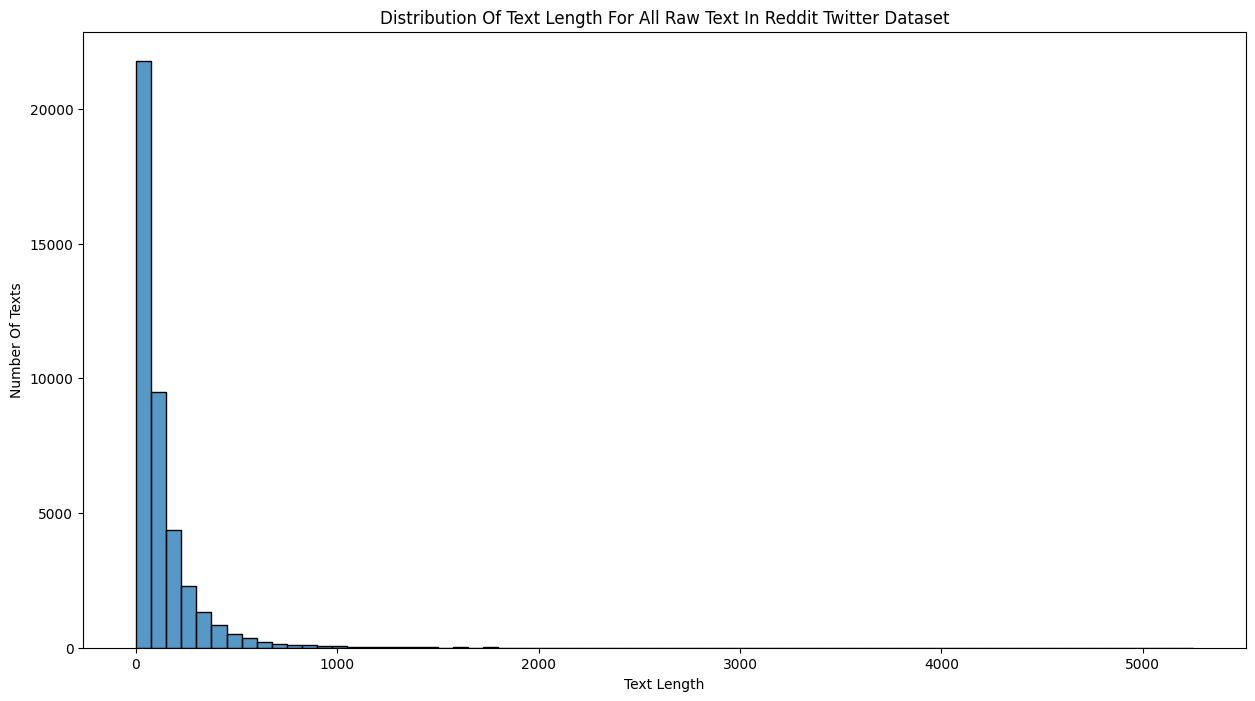

In [5]:
# Plotting The Distribution Of Text Length Using A Histogram
def plot_answer_lengths(df):
    df = df.copy(deep=True)
    df["Text Length"] = df["Raw Text"].apply(lambda text: len(text.split()))
    plt.figure(figsize=(15, 8))

    sns.histplot(data=df, x="Text Length", bins=70)

    plt.title("Distribution Of Text Length For All Raw Text In Reddit Twitter Dataset")
    plt.xlabel("Text Length")
    plt.ylabel("Number Of Texts")
    plt.show()

plot_answer_lengths(reddit_twitter)

**Key Observations:** 

1) **Right Skewed Distribution Present:** The majority of text samples are concentrated at shorter lengths, while a smaller number of samples extend to very long lengths. This creates a long right tail, indicating the presence of outliers with unusually long text.
   
2) **High Frequency of Short Texts:** Most samples appear to fall within a relatively low word count range (example: short posts or sentences). This is consistent with platforms like Twitter, where brevity is common.

3) **Presence of Long-Form Content:** There are some significantly longer texts, likely originating from Reddit posts or more detailed user expressions.
These contribute to the spread and variability of the distribution.

The dataset is dominated by short texts but includes a meaningful proportion of long-form content, which introduces variability that must be carefully handled during preprocessing to ensure robust and efficient model performance. 

Next, we proceed to examine the content of very short text samples. This is important because extremely short texts (fewer than 5 words) often provide limited contextual information and may not contribute meaningfully to predicting depression levels. Instead, they can introduce noise into the dataset and potentially reduce the model’s predictive performance. As such, we will analyze these short texts in greater detail and determine whether their removal is justified as part of the data cleaning process. We will take very short texts to be 5 words or fewer.

In [6]:
# Examining The Content Of Very Short Texts
def find_short_texts(df, min_text_length):
    df = df.copy(deep=True)
    df["Text Length"] = df["Raw Text"].apply(lambda x: len(x.split()))
    short_texts = df[df["Text Length"] < min_text_length]
    return short_texts.drop(["Text Length"], axis=1)

MIN_TEXT_LENGTH = 5
find_short_texts(df=reddit_twitter, min_text_length=MIN_TEXT_LENGTH)

,Raw Text,Depression Level
295,#NAME?,Minimum
1592,#NAME?,Minimum
2190,#NAME?,Minimum
2563,#NAME?,Minimum
5763,Venting : [removed],Moderate
...,...,...
41749,Me: Anxiety: ...unless?,Minimum
41757,💕💕💕,Minimum
41772,Actually genius.,Minimum
41776,Oh https://t.co/Fmh4GEFdSp,Minimum


Upon examining the rows corresponding to very short texts, we observe that such samples generally lack meaningful semantic content. Examples such as “#NAME?”, “Venting : [removed]”, and “No 🙂” provide little to no useful information for predicting depression levels. These entries often consist of stopwords, emojis, placeholders, links, or incoherent terms, all of which contribute minimal predictive value and instead introduce noise into the dataset.

In addition, the dataset contains duplicate entries. For instance, multiple rows share identical raw text (e.g., “#NAME?”) along with the same depression level label (“Minimum”). The presence of such duplicates can bias the model by over-representing certain patterns, leading to overfitting and reduced generalization performance on unseen data. Therefore, it is important to remove duplicate records to ensure a more balanced and reliable training process.

Furthermore, rows where the raw text contains fewer than five words will also be removed. These short texts typically lack sufficient context for meaningful interpretation and are unlikely to contribute positively to the model’s predictive capability. Overall, these data cleaning steps: removing semantically uninformative short texts and eliminating duplicate entries are essential to improving data quality and enhancing the robustness of the predictive model.

In [7]:
# Function To Remove Duplicates + Raw Text Fewer Than 5 Words
def clean_df(df, min_text_length):
    df = df.copy(deep=True)

    # Remove short texts
    df["Text Length"] = df["Raw Text"].apply(lambda text: len(text.split()))
    df = df[df["Text Length"] >= min_text_length]

    # Remove duplicated rows
    df = df.drop_duplicates(subset=["Raw Text"])

    # Map label to an integer score
    word_label_to_score = {"Minimum": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
    df["Depression Level"] = df["Depression Level"].apply(lambda word_label: word_label_to_score[word_label])

    # Rename columns to suit default column names accepted by Hugging Face
    df = df.rename(columns={"Depression Level": "labels", "Raw Text": "text"})

    # Drop columns
    df = df.drop(["Text Length"], axis=1)
    return df

reddit_twitter_cleaned = clean_df(df=reddit_twitter, min_text_length=MIN_TEXT_LENGTH)
reddit_twitter_cleaned.head()

,text,labels
0,"He said he had not felt that way before, sugge...",1
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,0
3,"until i met my new boyfriend, he is amazing, h...",1
4,October is Domestic Violence Awareness Month a...,2


--------------------------------------------------------------------------------------------------------------------------------------------------------
#### **Data Splitting**

After further cleaning the reddit_twitter dataset by removing rows with missing values, duplicates, and extremely short texts, we are now prepared to perform the train test split. Before proceeding, however, it is important to assess whether the class labels are balanced. Examining the distribution of each label (i.e., the counts of 0, 1, 2, and 3) is crucial because severe class imbalance can lead to biased model predictions and reduced overall accuracy, as the model may overfit to the majority class while underrepresenting minority classes. 

In [8]:
# Determining The Number Of Rows With Each Respective Label Type
cleaned_data_label_counts = reddit_twitter_cleaned["labels"].value_counts()
cleaned_data_label_counts

labels
3    10647
1    10642
0     6141
2     4356
Name: count, dtype: int64

We observe that the class distribution is highly imbalanced. Specifically, labels 3 (10,647 rows) and 1 (10,642 rows) occur far more frequently than labels 0 (6,141 rows) and 2 (4,356 rows). This imbalance indicates that without corrective measures, the model may be biased toward predicting 3 or 1, potentially resulting in lower overall accuracy. To address this issue and achieve a more balanced dataset, several strategies can be considered, including undersampling, oversampling and SMOTE.

In this context, we opted for **undersampling** because oversampling could introduce duplicate samples, while SMOTE might generate synthetic instances that do not accurately reflect the underlying data distribution. To ensure that the output is always the same, we set a SEED value of 42.

In [9]:
# Set a seed (ensure output is the same for every run)
SEED = 42

# Conduct undersampling
min_count_for_undersampling = cleaned_data_label_counts.min()

# Undersample all classes to this size
reddit_twitter_balanced = reddit_twitter_cleaned.groupby("labels").sample(n=min_count_for_undersampling, random_state=SEED).reset_index(drop=True)
reddit_twitter_balanced["labels"].value_counts()

labels
0    4356
1    4356
2    4356
3    4356
Name: count, dtype: int64

After the undersampling process, we observe that each class label (0, 1, 2, and 3) now contains 4,356 rows. The dataset is therefore evenly balanced, with no majority or minority classes. We are now ready to perform the train-test split.

For this project, the data will be divided as follows:
* 80% for the training set
* 10% for the validation set
* 10% for the test set

Accordingly, we will set `TRAIN_SIZE = 0.8` and `TEST_SIZE = 0.1`. The resulting subsets will be stored in three separate DataFrames: `train_df`, `val_df` and `test_df`.

In [10]:
# Performing The Train Test Split
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 0.8
TEST_SIZE = 0.1

# Get features and labels
X, y = reddit_twitter_balanced.drop(["labels"], axis=1), reddit_twitter_balanced["labels"]

# Split train from val and test
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, train_size=TRAIN_SIZE, stratify=y, random_state=SEED)

# Split val and test
test_size_wrt_remaining = TEST_SIZE / (1 - TRAIN_SIZE)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=test_size_wrt_remaining, stratify=y_val_test, random_state=SEED)

# Obtain final train and test data frames
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

After performing the train-test split, we will validate the resulting datasets by confirming that the total number of samples in the training, validation and test sets matches expectations. Additionally, we will ensure that the distribution of class labels within each subset is approximately consistent, so that no new imbalances are introduced. This can be achieved by visualizing the counts of each label across the three datasets using a 2×2 subplot.

**Total Number Of Rows** = 4356 * 4 = **17424 rows**

**Expected Number Of Rows In Train Set** = 80% * 17424 ~ **13939 rows**

**Expected Number Of Rows In Validation Set** = 10% * 17424 ~ **1742 rows**

**Expected Number Of Rows In Test Set** = 10% * 17424 ~ **1742 rows**

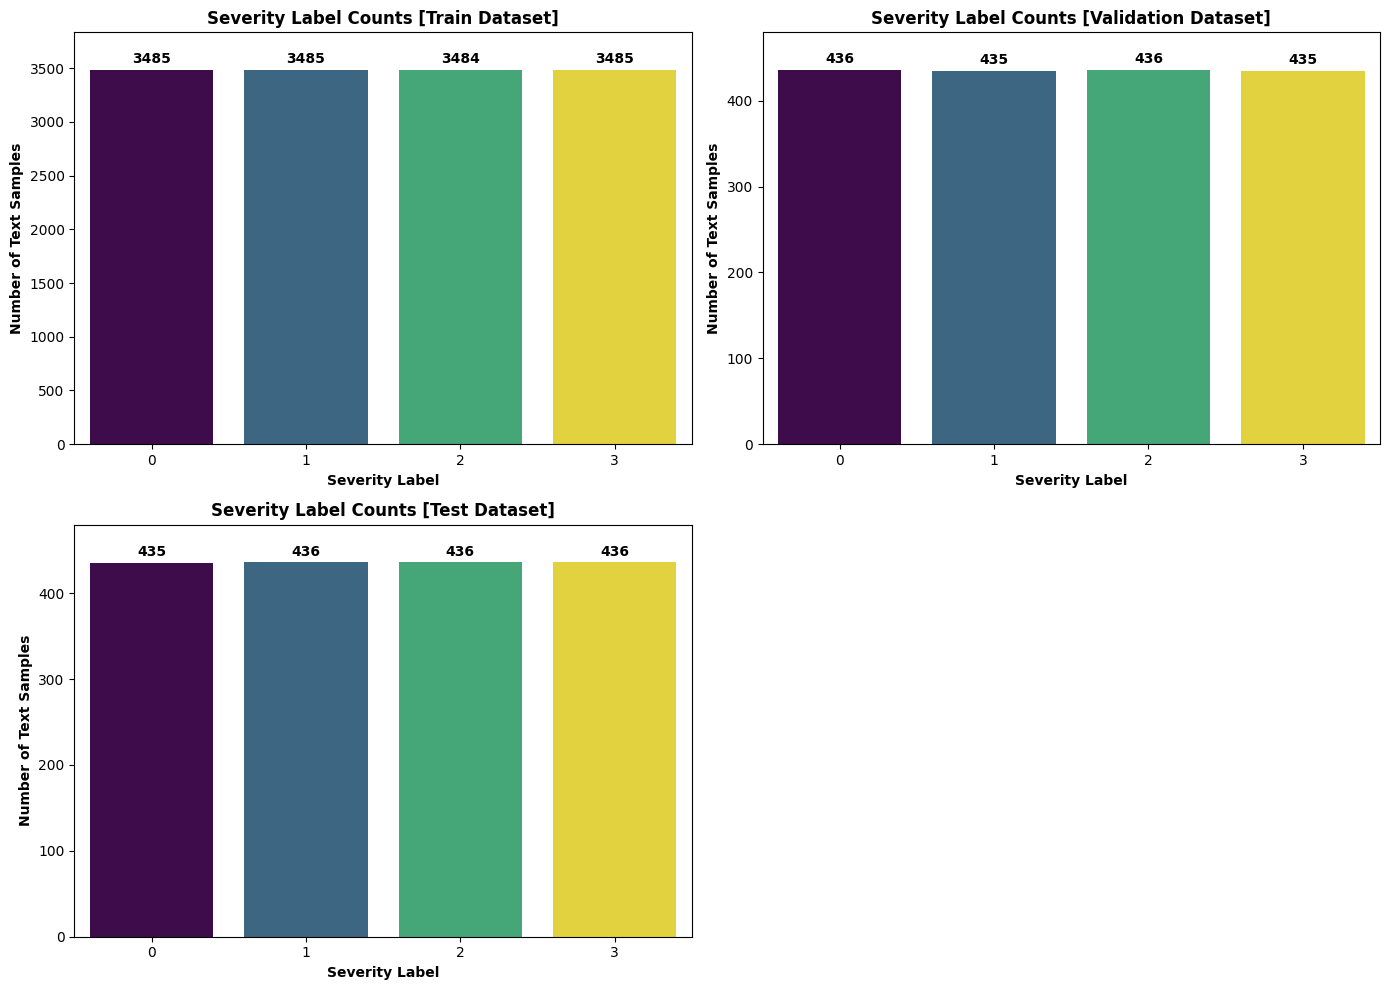

In [11]:
# Plotting The Number Of Text Of Each Class Label For Train, Validation And Test Datasets
def plot_value_counts_grid(train_df, val_df, test_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    datasets = [(train_df, "Train Dataset"), (val_df, "Validation Dataset"), (test_df, "Test Dataset")]

    for i, (df, title) in enumerate(datasets):
        level_counts = df["labels"].value_counts().reset_index()
        level_counts.columns = ["labels", "count"]
        level_counts = level_counts.sort_values("labels")
        ax = axes[i]
        sns.barplot(data=level_counts, x="labels", y="count", hue="labels", palette="viridis", legend=False, ax=ax)

        y_max = level_counts["count"].max()
        ax.set_ylim(0, y_max * 1.1)

        # Add annotations
        for _, row in level_counts.iterrows():
            ax.text(row["labels"], row["count"] + y_max * 0.01, f"{row['count']}", ha="center", va="bottom", fontsize=10, fontweight="bold")
        ax.set_title(f"Severity Label Counts [{title}]", fontsize=12, fontweight="bold")
        ax.set_xlabel("Severity Label", fontsize=10, fontweight="bold")
        ax.set_ylabel("Number of Text Samples", fontsize=10, fontweight="bold")

    # Turn off bottom-right subplot
    axes[3].axis("off")
    plt.tight_layout()
    plt.show()

plot_value_counts_grid(train_df, val_df, test_df)

For checking purposes: 

**Actual Number Of Rows In Train Dataset** = 3485 + 3485 + 3484 + 3485 = **13939 rows** ✅

**Train Dataset Is Balanced?** ✅ (3484 to 3485 rows, +- 1 row)

**Actual Number Of Rows In Validation Dataset** = 436 + 435 + 436 + 435 = **1742 rows** ✅

**Validation Dataset Is Balanced?** ✅ (435 to 436 rows, +- 1 row)

**Actual Number Of Rows In Test Dataset** = 435 + 436 + 436 + 436 = **1743 rows** ✅

**Test Dataset Is Balanced?** ✅ (435 to 436 rows, +- 1 row)


The train, validation and test dataset are now balanced with the correct number of rows. The train test split is applied correctly and now we can proceed to train the model.

--------------------------------------------------------------------------------------------------------------------------------------------------------
